# Classical Operator Backbone

This notebook explains why the project keeps NumPy and SciPy sparse as the first live tooling layer.

Corpus anchors: `QRE2` (`eq:streaming`, `eq:LBE_col_shift_matrix`, `eq:F1`, `eq:F2`), `QRE4`, `CAR7`, `IO4`, `IO5`, `IO7`, `IO8`.

Compact object: the periodic D2Q9 streaming matrix `S` for a tiny grid.


The core check is not quantum yet:

```text
g_next = S (g + F1 g + F2 (g tensor g))
```

Before choosing a quantum SDK, we need to know whether the classical object has the sparsity, locality, and observable behavior that a route note would later count.


tooling atlas output directory: .cache\tooling_atlas


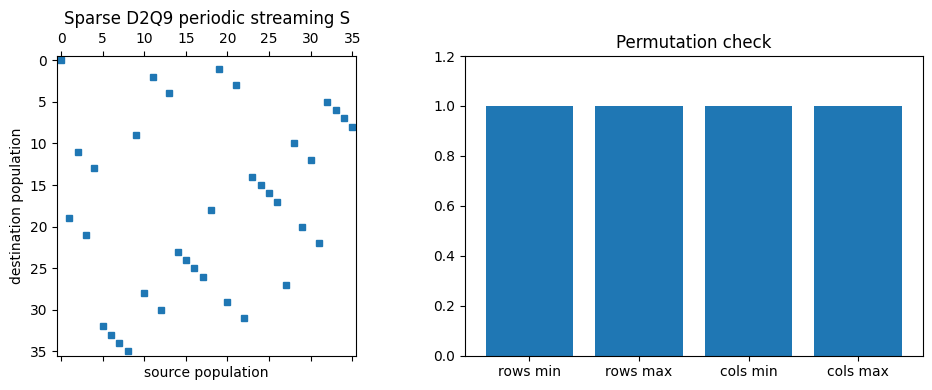

falsifiable check: S is a 36x36 sparse permutation for a 2x2 D2Q9 grid


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

from pq_cfd import _qre2_sparse as qre2_sparse

spatial_shape = (2, 2)
streaming = qre2_sparse.build_sparse_streaming_matrix(spatial_shape)
row_sums = np.asarray(streaming.sum(axis=1)).ravel()
col_sums = np.asarray(streaming.sum(axis=0)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].spy(streaming, markersize=5)
axes[0].set_title('Sparse D2Q9 periodic streaming S')
axes[0].set_xlabel('source population')
axes[0].set_ylabel('destination population')
axes[1].bar(['rows min', 'rows max', 'cols min', 'cols max'], [row_sums.min(), row_sums.max(), col_sums.min(), col_sums.max()])
axes[1].set_ylim(0, 1.2)
axes[1].set_title('Permutation check')
plt.tight_layout()
plt.show()

assert streaming.shape == (36, 36)
assert streaming.nnz == 36
assert np.allclose(row_sums, 1.0)
assert np.allclose(col_sums, 1.0)
print('falsifiable check: S is a 36x36 sparse permutation for a 2x2 D2Q9 grid')


In [2]:
# Optional JAX scout: do not fail if JAX is absent.
if has_module('jax'):
    import jax
    import jax.numpy as jnp
    values = jnp.asarray([streaming.nnz, streaming.shape[0]], dtype=jnp.float32)
    print('JAX available:', jax.__version__, 'demo vector:', values)
else:
    print('JAX scout blocked: not installed in the maintained environment. Keep as WATCH-TOOL until a scale/sweep need appears.')


JAX scout blocked: not installed in the maintained environment. Keep as WATCH-TOOL until a scale/sweep need appears.


## What This Cannot Prove

Sparse classical validation does not provide a block encoding, oracle, loading model, success probability, or measurement/sample complexity. It only tells us what object later tools would have to represent.
